<script src="/course_model/toc.js"></script>

# Linear Regression

Linear Regression is our most important prediction tool. It uses multiple numerical independent variables to predict a single output/dependent variable. We generally use the OLS (ordinary least squares) algorithm.

**Outcomes**:
- Explain when to use linear regression and its main assumptions
- Explain the difference between test/train splits versus p-values for model evaluation for reducing overfitting
- Explain the accuracy and statistical significance of a linear regression model and individual coeffiecients
- Explain R^2, RMSE, residuals, coefficients, and p-values
- Draw a graph of a linear regression model from an equation
- Explain multicollinearity and how to detect it
- Explain normality of residuals (or homoscedasticity)

**Links**:
- [Quizlet](https://quizlet.com/1127682970/ml05-ols-regression-flash-cards/?i=2up6jq&x=1jqt)
- [Regression Error Template](regression-simple-error-problem.docx)
- [template](template.ipynb) and [data files](statelife.csv)

**Good Resources**:
- [Linear Regression in 3 minutes](https://www.youtube.com/watch?v=3dhcmeOTZ_Q)
- [Multiple regression in R](https://www.youtube.com/watch?v=hokALdIst8k)
- [Multiple regression in theory](https://www.youtube.com/watch?v=zITIFTsivN8)
- [Multiple linear regression tutorial](https://bradleyboehmke.github.io/HOML/linear-regression.html)
- [Should we use a p<0.05 in science?](https://www.tandfonline.com/doi/full/10.1080/00031305.2019.1583913)
- [Linear Regression Visual](https://mlu-explain.github.io/linear-regression/)


## Key concepts in regression

When to use Linear Regression:

- Linear regression assumes a *linear* relationship between the independent variables and the output variable. 
    - If the relationship is non-linear, we may need to transform the inputs (e.g., log, square root, polynomial) to achieve linearity.
- The output variable is a *continuous* numerical variable. 
    - Logistic regression is used when the output variable is categorical (e.g., yes/no, true/false, 0/1).
- Train/test split
    - We do not typically use test/train split in *classical* regression. Instead, we look at individual coefficients and their p-values to determine significance, as well as overall model metrics like R^2 and RMSE.

![Curve Fitting](curve_fitting.jpg)


Interpretation:

- Overall Model 
    - R^2 value indicates the proportion of variance in the dependent variable that can be explained by the independent variables.
        - We want a higher R^2 value (closer to 1) as it indicates a better fit.
        - If we have multiple independent variables, we instead use *adjusted* R^2.
            - This adjusts the R^2 value based on the number of predictors in the model, providing a penalty for adding predictors.
    - RMSE (root mean squared error) indicates the average distance between the predicted values and the actual values.
        - We want a lower RMSE value as it indicates better predictive accuracy.
    - Residuals are the differences between predicted and actual values
        - Residuals should be normally distributed around zero.
        - We can check this with a histogram of residuals.
- Individual Predictors
    - Each independent variable has a *coefficient* that indicates the strength and direction of its relationship with the output variable.
        - A positive coefficient means that as the independent variable increases, the output variable also increases.
        - A negative coefficient means that as the independent variable increases, the output variable decreases.
    - Each independent variable also has a *p-value* that indicates the statistical significance of its relationship with the output variable.
        - A common threshold for significance is p < 0.05, meaning there is less than a 5% chance that the observed relationship is due to random chance.
        - However, this threshold is arbitrary and should be considered in context.


Weaknesses / Assumptions:

- *Overfitting* occurs when the model captures noise in the training data rather than the underlying pattern. This can lead to poor performance on new, unseen data.
    - Our primary tool to avoid overfitting is looking at individual coefficients and their p-values to determine significance.
- *Multicollinearity* is a problem when independent variables are highly correlated with each other. This can make it difficult to determine the individual effect of each variable on the output.
- *Normality of residuals*: The residuals should be approximately normally distributed. This is important for hypothesis testing and constructing confidence intervals.
    - We can check this with a histogram of residuals.
- All input variables should be continuous or discrete numerical variables. 
    - Categorical variables need to be converted to dummy/indicator variables. I.E., if we have a categorical variable with three levels (A, B, C), we would create two dummy variables (is_B, is_C) where is_B = 1 if the observation is B and 0 otherwise, and is_C = 1 if the observation is C and 0 otherwise. Level A would be the reference level.



## Step 1: Understand your data

### Check field types and values

First we want to make sure that we understand our data. Begin by visually scanning the table.
Then, use some functions to show what values are present in the data.


In [2]:
# Check field types and values
import pandas as pd
import numpy as np

# Sales table
df_raw = pd.DataFrame({
    'sales_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'sales_as_text': ['1,000', '2,000', '2,500', '10,000', '1,900', np.nan, '3,000', '4,000', '5,000', '6,000'],
    'profit': [0, 400, 1600, 6250, 240, np.nan, 900, 1600, 500, 600],
    'office_size': [16, 1, 2, 3, 1, 3, 2, 4, 5, 2],
    'closed': [True, False, True, False, False, False, True, True, False, True],
    'state': ['ca', 'ca', np.nan, 'NY', 'ca', np.nan, 'NY', 'NY', 'ca', 'ca'],
})

print("DataFrame dtypes:")
print(df_raw.dtypes)
df_raw.describe()

DataFrame dtypes:
sales_id           int64
sales_as_text        str
profit           float64
office_size        int64
closed              bool
state                str
dtype: object


,sales_id,profit,office_size
count,10.00000,9.000000,10.000000
mean,5.50000,1343.333333,3.900000
std,3.02765,1922.862450,4.433459
min,1.00000,0.000000,1.000000
25%,3.25000,400.000000,2.000000
50%,5.50000,600.000000,2.500000
75%,7.75000,1600.000000,3.750000
max,10.00000,6250.000000,16.000000


### Graph your data

You want to look for the distribution of values in each column, and the relationships between columns.

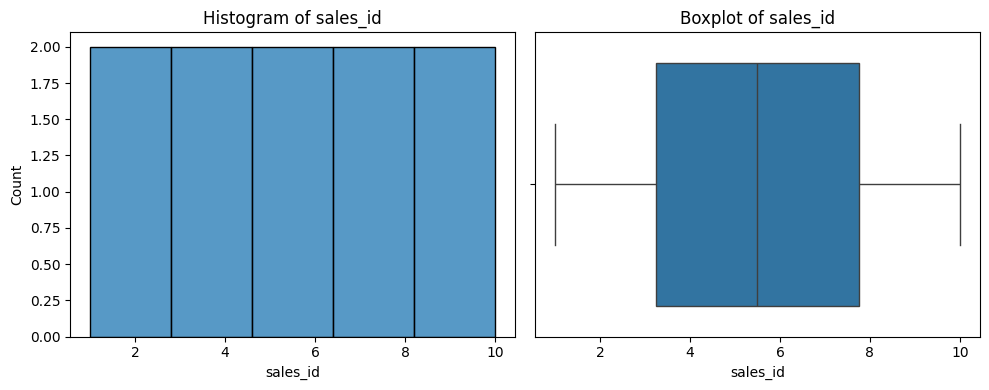

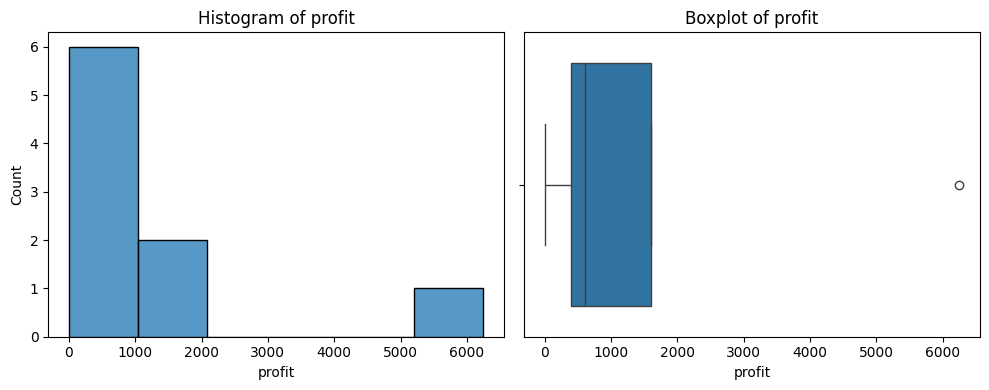

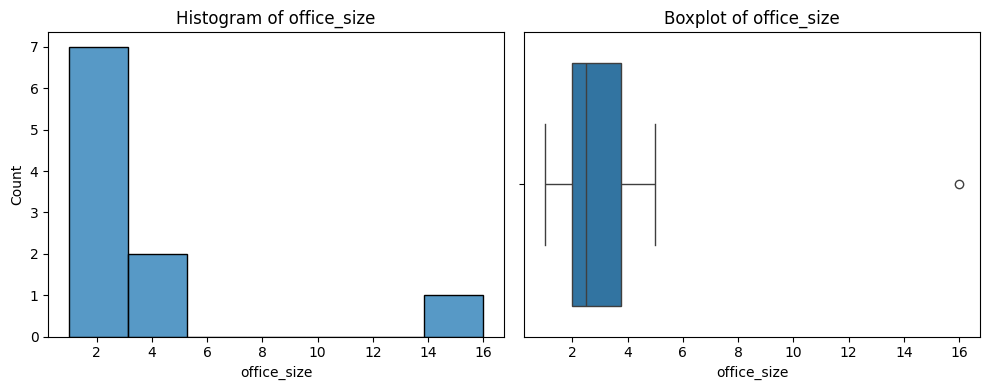

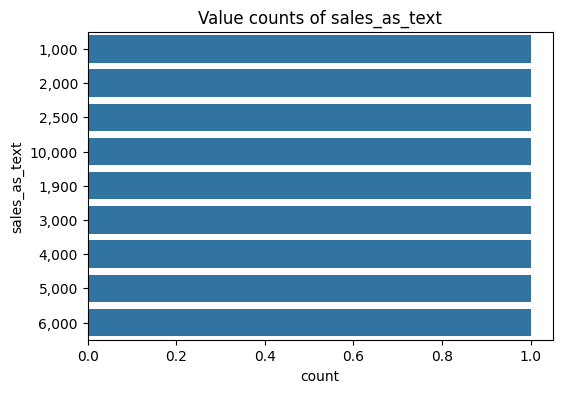

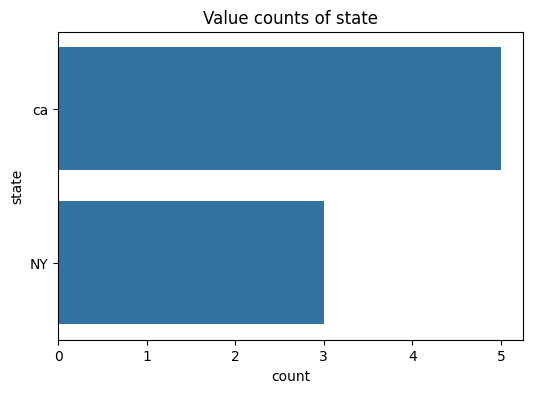

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_raw.copy()

number_columns = df.select_dtypes(include=['number']).columns.tolist()
text_columns = df.select_dtypes(include=['string', 'category']).columns.tolist()

# Print a histogram and boxplot for each numeric column
for col in number_columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col])
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

# Print a chart showing the distribution of values for each text column
for col in text_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Value counts of {col}')
    plt.show()

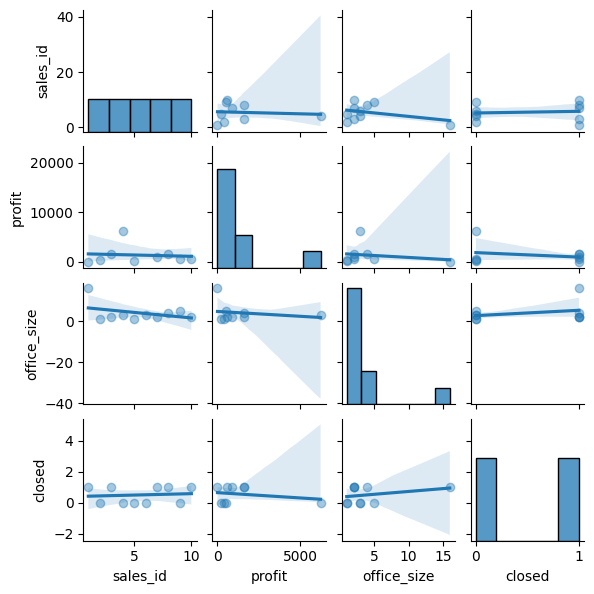

In [6]:
# Plot a pairs printout of each of the numeric variables
# Note that we use the alpha to set the visibility of the points to 0.01 to avoid overplotting. This also works well for large datasets.

sns.pairplot(df, kind='reg', height=1.5, plot_kws={'scatter_kws': {'alpha': 0.4}})
plt.show()

## Step 2: Regression with Python


Key items:

- Residuals = errors in each row between actual & predicted
- Standard Error = the squared difference between the predicted and actual values. 
- Coefficients:
  - Estimate: value of the change in input to output
  - Standard Error: averages squared diff between prediction / actual
  - p Value: probability of the estimate being a result of random chance
- Residual standard error: the overall avg difference between actual
    and predicted for the entire model.
  - Adj R^2,  the % of variation explained by the model

In [ ]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

X = df[['office_size', 'sales_as_number', 'is_ny']]
y = df['profit']

# Fit the model
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
predictions = model.predict(X)
print(model.summary())



## Step 3: Interpret results

Important parts of the summary output:

- *Dep. Variable: profit*: What is our output variable?
- *Adj. R-squared*: What is the R-squared value, with an appropriate penalty for number of variables?
- *No. Observations*: How many observations were used in the model?

What explains each variable in our model?

- *coef*: The estimated coefficient for each independent variable. This represents the change in the dependent variable for a one-unit change in the independent variable, holding all other variables constant.
- *t*: The t-statistic for the hypothesis test that the coefficient is equal to zero.
- *P>/|t/|*: The probability of this result, given a random underlying variable. A low p-value (typically < 0.05) suggests that a good relationship exists.
- *[0.025 0.975]*: The 95% confidence interval for the coefficient. This means that we are 95% confident that the true coefficient lies within this interval.

### RMSE

RMSE is the squared difference of each error. (https://www.statology.org/how-to-interpret-rmse/)[Link to a good reference]

Calculate the squared difference of each point,
(10 - 10)^2 + (12 - 10)^2 + (8 - 10)^4 = 20

Divide by the number of observations, and take the square root.
(20 / 3) ^ .5 = 2.58

### Residuals

We may also want to see the difference between our prediction and actual values. 
(10 - 10), (12 - 10), (8 - 10) --> (0, 2, -2)

So, the RSME is the square root of the variance. This is the average distance between observed data values and predicted.

### R-squared

The coefficient of determination tells us the *proportion* of variance in our dependent variable that can be explained by our independent variables.

It ranges from 0 to 1. Generally, the higher the number the better the prediction.

We will *always* use the adjusted R^2 when using multiple coeffients. This applies a small penalty for using additional columns.

In [ ]:

# Calculate error metrics

# Find the residuals, which are the differences between the observed and predicted values
resid = model.resid

# The fitted values are the predicted values from the model
fitted = model.fittedvalues

# Calculate RMSE 
rmse_value = np.sqrt(np.mean(resid*resid))
print(f"RMSE: {rmse_value}")

# Calculate R²
r2_value = model.rsquared
print(f"R²: {r2_value}")

# Plot residuals
sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha': 0.7})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.axhline(0, color='red', linestyle='--')
plt.show()